In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Everything is working!")

Everything is working!


In [6]:
df = pd.read_csv("../data/Mall_Customers.csv")

In [49]:
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [46]:
df.shape

(200, 6)

In [47]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
 5   Cluster                 200 non-null    int32
dtypes: int32(1), int64(4), str(1)
memory usage: 8.7 KB


In [10]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [11]:
df.duplicated().sum()


np.int64(0)

In [12]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [20]:
df["Gender"].value_counts()


Gender
Female    112
Male       88
Name: count, dtype: int64

In [14]:
print("Age range:", df["Age"].min(), "-", df["Age"].max())

print(
    "Income range:",
    df["Annual Income (k$)"].min(),
    "-",
    df["Annual Income (k$)"].max()
)

print(
    "Spending Score range:",
    df["Spending Score (1-100)"].min(),
    "-",
    df["Spending Score (1-100)"].max()
)

Age range: 18 - 70
Income range: 15 - 137
Spending Score range: 1 - 99


In [15]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [16]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [17]:
df.rename(columns={"Genre": "Gender"}, inplace = True)

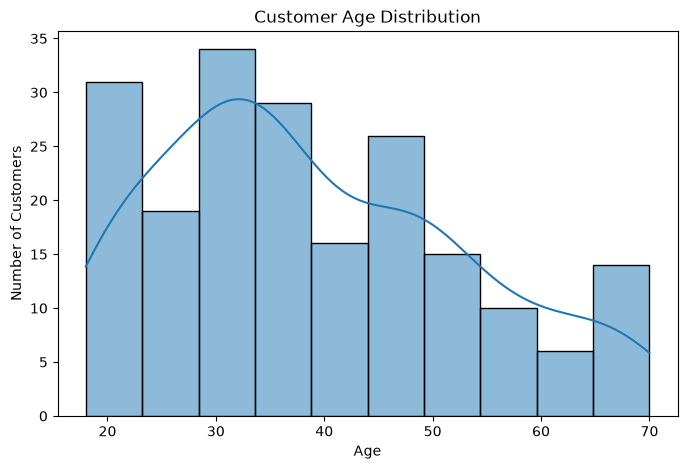

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Age"], bins=10, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

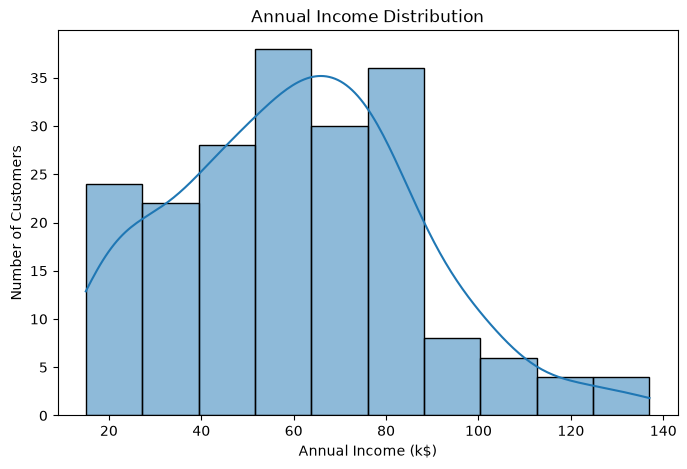

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Annual Income (k$)"], bins=10, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.show()

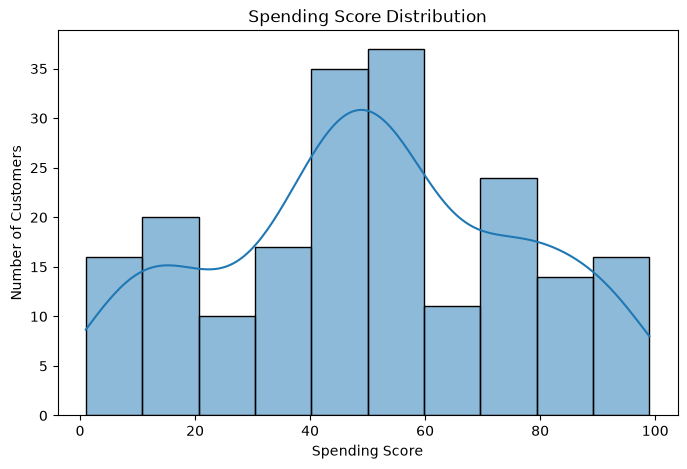

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Spending Score (1-100)"], bins=10, kde=True)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")

plt.show()

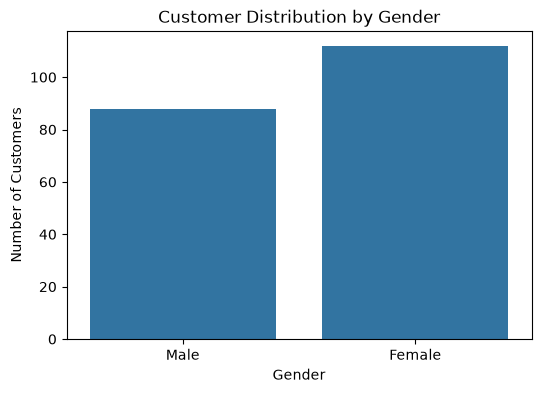

In [18]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Gender")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()


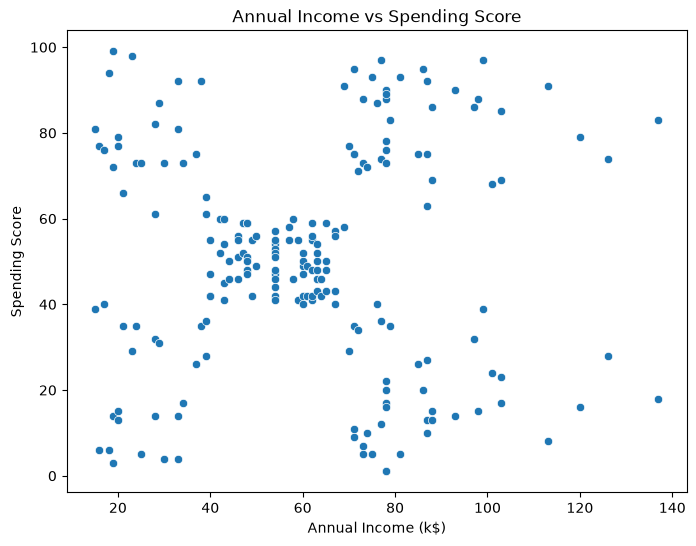

In [19]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)"
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

In [20]:
numeric_df = df[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
]

correlation = numeric_df.corr()

correlation

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


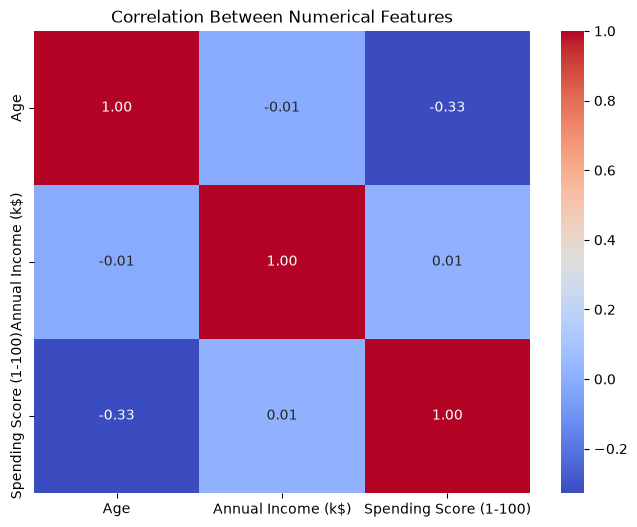

In [21]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")

plt.show()

In [22]:
X = df[
    ["Annual Income (k$)", "Spending Score (1-100)"]
]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [23]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [26]:
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

In [27]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=["Annual Income (k$)", "Spending Score (1-100)"]
)

X_scaled.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [28]:
from sklearn.cluster import KMeans

In [29]:
inertia = []

In [30]:
for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

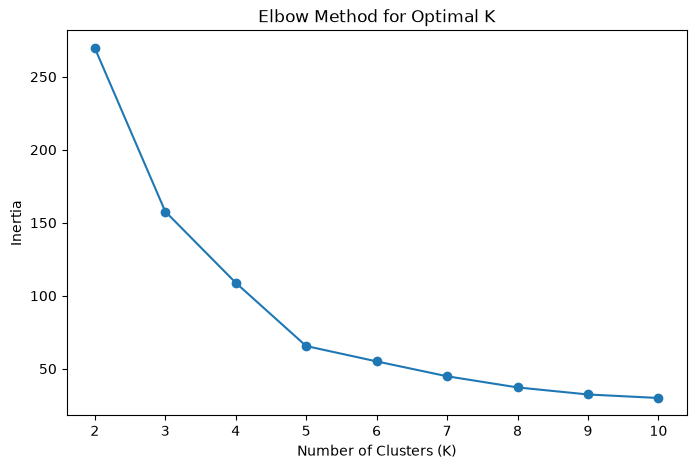

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

In [32]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

In [33]:
n_clusters=5

In [34]:
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [35]:
df["Cluster"]


0      4
1      2
2      4
3      2
4      4
      ..
195    1
196    3
197    1
198    3
199    1
Name: Cluster, Length: 200, dtype: int32

In [36]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [37]:
df["Cluster"].value_counts().sort_index()

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

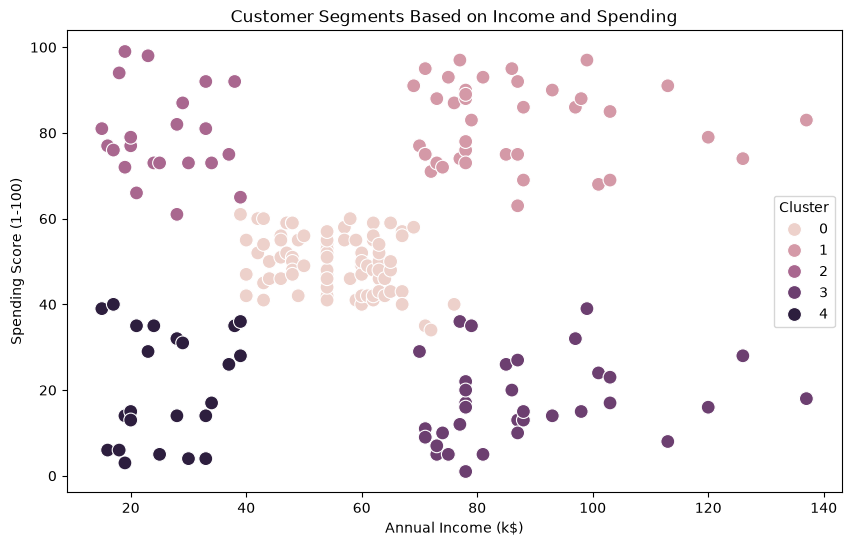

In [38]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    s=100
)

plt.title("Customer Segments Based on Income and Spending")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")

plt.show()

In [39]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

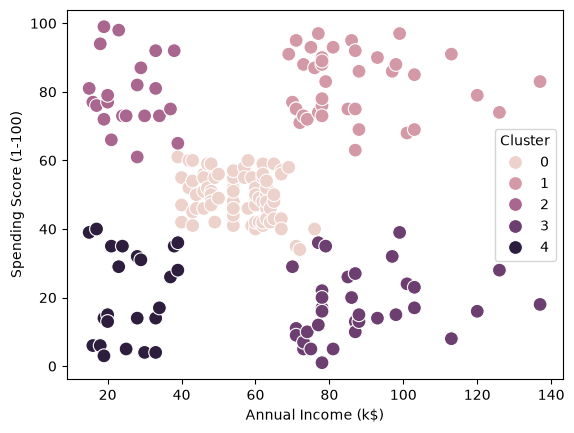

In [50]:
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    s=100
)